# Min-Max Scaling

Min-Max Scaling is a feature scaling technique that transforms numerical features into a fixed range.

The most common range is:

0 to 1

The formula is:

x_scaled = (x - x_min) / (x_max - x_min)

Where:

- x = Original value
- x_min = Minimum value
- x_max = Maximum value

Min-Max Scaling preserves the relative relationships between the observations while changing their scale.

## Why Do We Need Min-Max Scaling?

Consider two features:

Age:
20, 25, 30, 35, 40

Salary:
25000, 40000, 60000, 90000, 150000

These features have very different numerical ranges.

Min-Max Scaling transforms them into a common range, making them more comparable for algorithms that are sensitive to feature magnitude.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Age": [20, 25, 30, 35, 40],
    "Salary": [25000, 40000, 60000, 90000, 150000],
    "Experience": [1, 3, 5, 8, 12]
})

df

,Age,Salary,Experience
0,20,25000,1
1,25,40000,3
2,30,60000,5
3,35,90000,8
4,40,150000,12


In [2]:
print("Minimum:")
print(df.min())

print("\nMaximum:")
print(df.max())

Minimum:
Age              20
Salary        25000
Experience        1
dtype: int64

Maximum:
Age               40
Salary        150000
Experience        12
dtype: int64


## Manual Min-Max Scaling

The formula is:

x_scaled = (x - x_min) / (x_max - x_min)

For example, if:

x = 30
x_min = 20
x_max = 40

Then:

x_scaled = (30 - 20) / (40 - 20)

x_scaled = 10 / 20

x_scaled = 0.5

Therefore, 30 becomes 0.5 after Min-Max Scaling.

In [3]:
df_manual = df.copy()

for column in df.columns:
    min_value = df[column].min()
    max_value = df[column].max()
    
    df_manual[column] = (
        (df[column] - min_value) /
        (max_value - min_value)
    )

df_manual

,Age,Salary,Experience
0,0.00,0.00,0.000000
1,0.25,0.12,0.181818
2,0.50,0.28,0.363636
3,0.75,0.52,0.636364
4,1.00,1.00,1.000000


## Using Scikit-Learn

Scikit-learn provides `MinMaxScaler` to perform Min-Max Scaling easily.

The default feature range is:

0 to 1

In [4]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_scaled

,Age,Salary,Experience
0,0.00,0.00,0.000000
1,0.25,0.12,0.181818
2,0.50,0.28,0.363636
3,0.75,0.52,0.636364
4,1.00,1.00,1.000000


In [6]:
print("Minimum values:")
print(df_scaled.min())

print("\nMaximum values:")
print(df_scaled.max())

Minimum values:
Age           0.0
Salary        0.0
Experience    0.0
dtype: float64

Maximum values:
Age           1.0
Salary        1.0
Experience    1.0
dtype: float64


## Using a Custom Range

Min-Max Scaling does not have to use 0 to 1.

We can specify a custom range using the `feature_range` parameter.

For example:

`feature_range=(-1, 1)`

will scale the features between -1 and 1.

In [7]:
scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

df_scaled_custom = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_scaled_custom

,Age,Salary,Experience
0,-1.0,-1.00,-1.000000
1,-0.5,-0.76,-0.636364
2,0.0,-0.44,-0.272727
3,0.5,0.04,0.272727
4,1.0,1.00,1.000000


In [8]:
print("Original Data:")
display(df)

print("\nMin-Max Scaled Data:")
display(df_scaled)

Original Data:


,Age,Salary,Experience
0,20,25000,1
1,25,40000,3
2,30,60000,5
3,35,90000,8
4,40,150000,12



Min-Max Scaled Data:


,Age,Salary,Experience
0,0.00,0.00,0.000000
1,0.25,0.12,0.181818
2,0.50,0.28,0.363636
3,0.75,0.52,0.636364
4,1.00,1.00,1.000000


## Visualization

Let's visualize the data before and after Min-Max Scaling.

After scaling, all features should fall within the selected range.

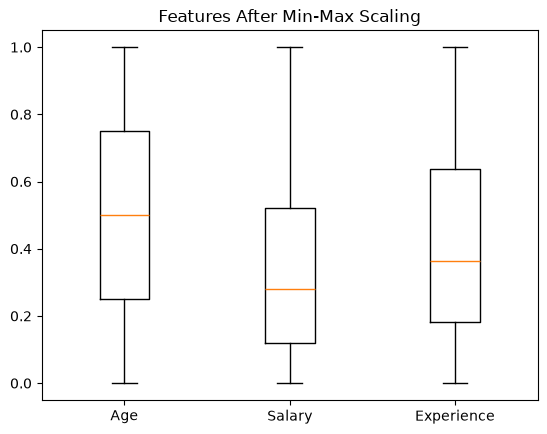

In [9]:
import matplotlib.pyplot as plt

plt.boxplot(df_scaled)

plt.title("Features After Min-Max Scaling")
plt.xticks(
    range(1, len(df.columns) + 1),
    df.columns
)

plt.show()